In [70]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline
plt.rc('text', usetex=True)

import sys
import importlib
sys.path.append('../code/')
import helper

In [2]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams.update({
    'axes.linewidth': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "black",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"})

In [3]:
directory = '../data/mssa_channels_kiyan_fast/'

fname_m0_amp = directory+'m0_amp_bins_j20_t16.dat'

fname_m1_amp = directory+'m1_amp_bins_j20_t16.dat'
fname_m1_pitch = directory+'m1_pitch_bins_j20_t16.dat'
fname_m1_rel_amp = directory+'m1_amp_rel_bins_j20_t16.dat'

fname_m2_amp = directory+'m2_amp_bins_j20_t16.dat'
fname_m2_pitch = directory+'m2_pitch_bins_j20_t16.dat'
fname_m2_rel_amp = directory+'m2_amp_rel_bins_j20_t16.dat'


coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)
coefs_m1_pitch0 = pyEXP.coefs.Coefs.factory(fname_m1_pitch)
coefs_m2_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m2_rel_amp)
coefs_m2_pitch0 = pyEXP.coefs.Coefs.factory(fname_m2_pitch)

coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()
coefs_m1_pitch = coefs_m1_pitch0.deepcopy()
coefs_m2_rel_amp = coefs_m2_rel_amp0.deepcopy()
coefs_m2_pitch = coefs_m2_pitch0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


#### Plot the Data

In [31]:
# To get colorbar
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [51]:
coefs_m1_pitch0.getAllCoefs()

array([[-0.56982497, -0.05474229, -0.88990708, ..., -0.25785295,
        -0.09518205, -1.57079633],
       [-0.66093446, -0.44351547, -0.79284024, ..., -0.12451897,
        -0.20077734, -1.57079633],
       [-0.44475372, -0.78547642, -0.94088828, ..., -0.11250197,
        -1.57079633, -0.21212862],
       ...,
       [-1.57079633, -1.57079633, -1.54453296, ..., -1.57079633,
        -0.07573246, -0.0670745 ],
       [-0.16931645, -0.51947282, -0.84742609, ..., -1.57079633,
        -1.57079633, -1.07627513],
       [-0.45962564, -0.19392233, -1.57079633, ..., -0.06914377,
        -1.57079633, -0.06278906]])

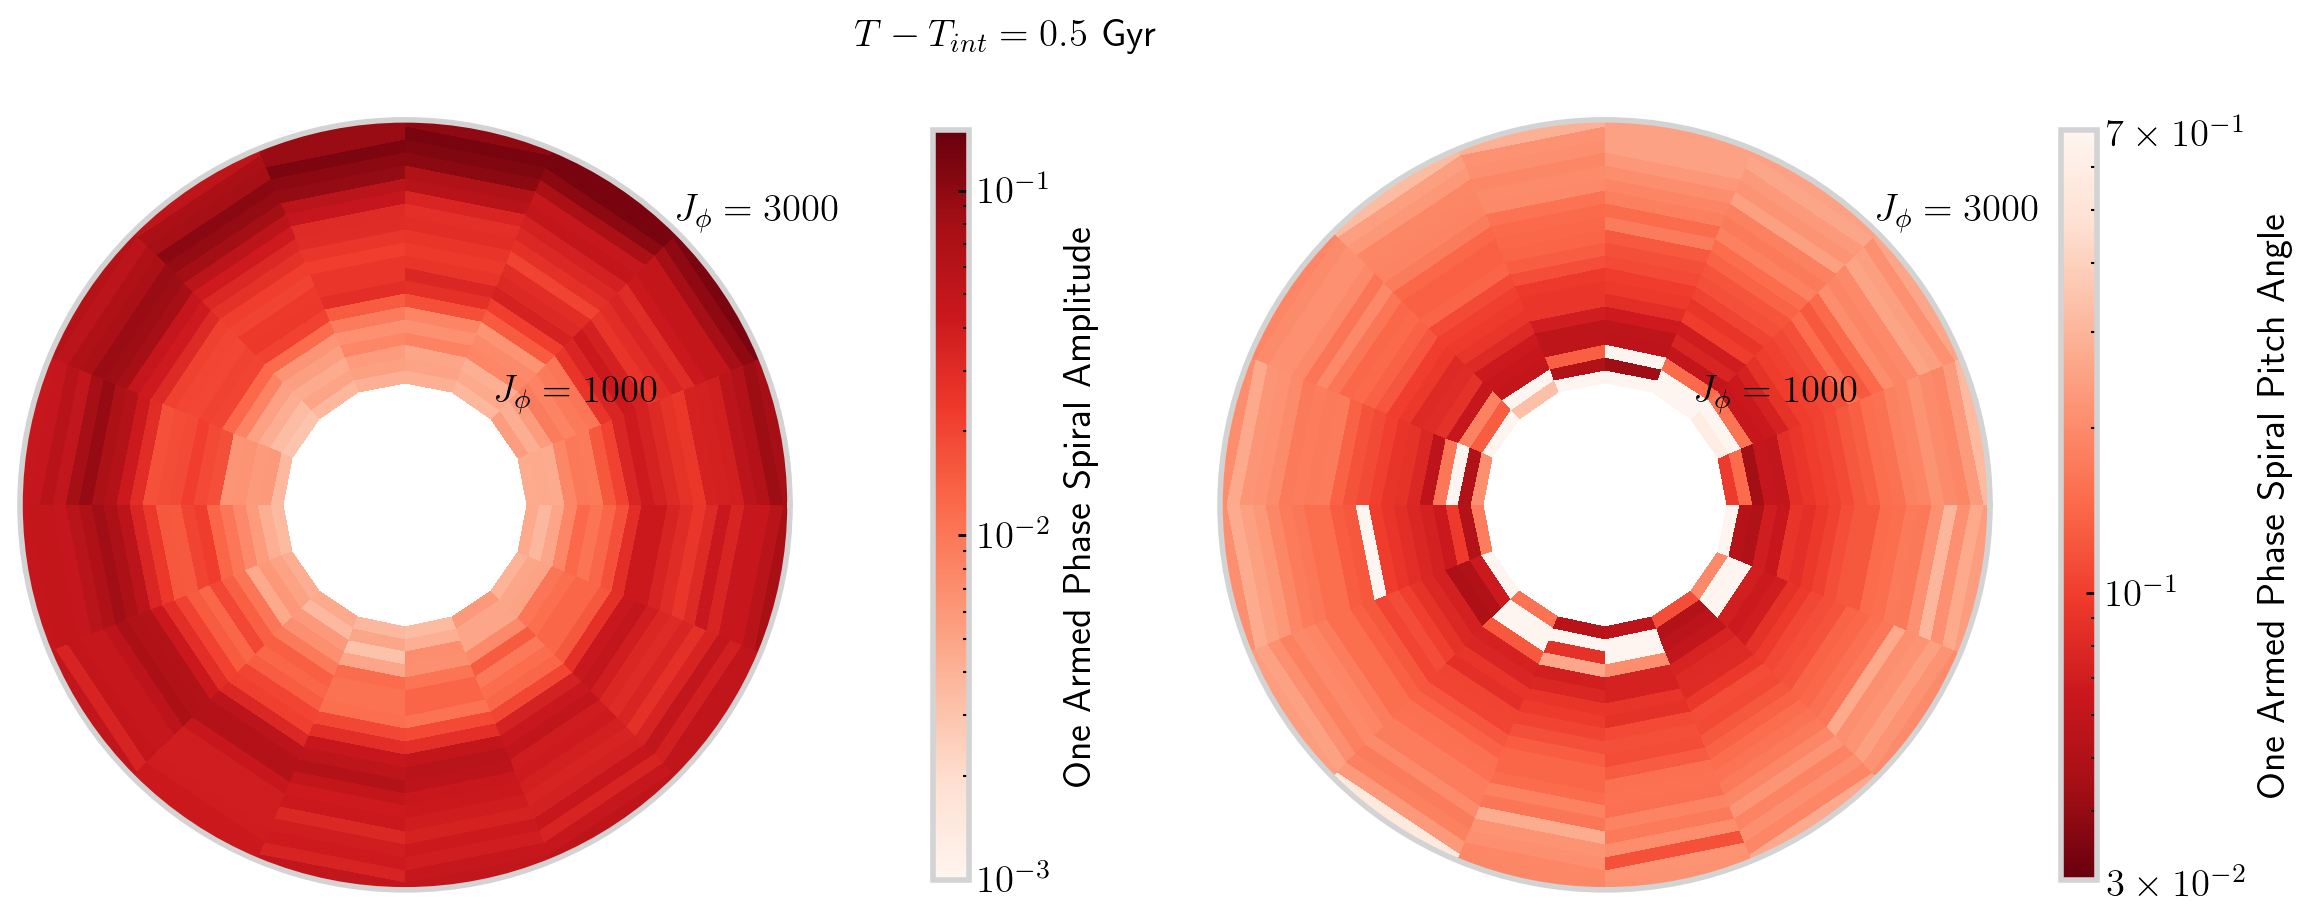

In [105]:
fig, [ax1, ax2] = plt.subplots(1,2, figsize=(12,5), subplot_kw={'projection': 'polar'}, gridspec_kw={'wspace':0.0, 'left':0, 'right':1})
amp_vmax=0.5
im1 = ax1.pcolormesh(T, J, np.reshape(coefs_m1_rel_amp0.getAllCoefs()[:,52], T.shape, 'F'), 
                          cmap='Reds', rasterized=True,
                          norm=mpl.colors.LogNorm(vmin=1e-3, vmax=0.15))


im2 = ax2.pcolormesh(T, J, np.reshape(-coefs_m1_pitch0.getAllCoefs()[:,52], T.shape, 'F'), 
                          cmap='Reds_r', rasterized=True,
                          norm=mpl.colors.LogNorm(vmin=3e-2, vmax=0.7))

fig.subplots_adjust(right=0.85)
cbar_ax1 = fig.add_axes([0.47, 0.12, 0.015, 0.75])
cbar_ax2 = fig.add_axes([0.94, 0.12, 0.015, 0.75])
cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar2 = fig.colorbar(im2, cax=cbar_ax2)
# cbar1.set_ticks(ticks=[3e-2, 1e-1, 7e-1])
cbar2.set_ticks(ticks=[3e-2, 1e-1, 7e-1], labels=[r'$3 \times 10^{-2}$', r'$10^{-1}$', r'$7 \times 10^{-1}$'])
cbar1.set_label('One Armed Phase Spiral Amplitude')
cbar2.set_label('One Armed Phase Spiral Pitch Angle')


for ax in [ax1, ax2]:
    ax.set_yticks([np.min(jphi_c), np.max(jphi_c)], labels=[r'$J_\phi=1000$', r'$J_\phi=3000$'])
    ax.set_rlabel_position(45)
    ax.set_rmax(np.max(jphi_c))
    ax.tick_params(left = False, right = False , labelleft = True ,
                         labelbottom = False, bottom = False)
    ax.grid(visible=False)

fig.suptitle(r'$T - T_{int} = 0.5$ Gyr', fontsize=14)
plt.savefig('../figures/kiyan_fast_figures/m1_both/data_m1_amplitude_pitch.pdf')
plt.show()

#### Run mSSA

In [4]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m1_pitch.getAllCoefs()))
times = coefs_m1_pitch.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]
keylst_m1_pitch = [[i] for i in range(n_channels)]
keylst_m2_amp = [[i] for i in range(n_channels)]
keylst_m2_pitch = [[i] for i in range(n_channels)]

config = {"snails_m1_amp_rel": (coefs_m1_rel_amp, keylst_m1_amp, []),
          "snails_m1_pitch": (coefs_m1_pitch, keylst_m1_pitch, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [5]:
fig_dir = '../figures/kiyan_fast_figures/m1_both/'

In [6]:
ev = mssa.eigenvalues()

shape U = 88032 x 132
shape Y = 132 x 88032


In [7]:
coefs_m1_rel_amp.zerodata()
coefs_m1_pitch.zerodata()
mssa.reconstruct([*range(30)])

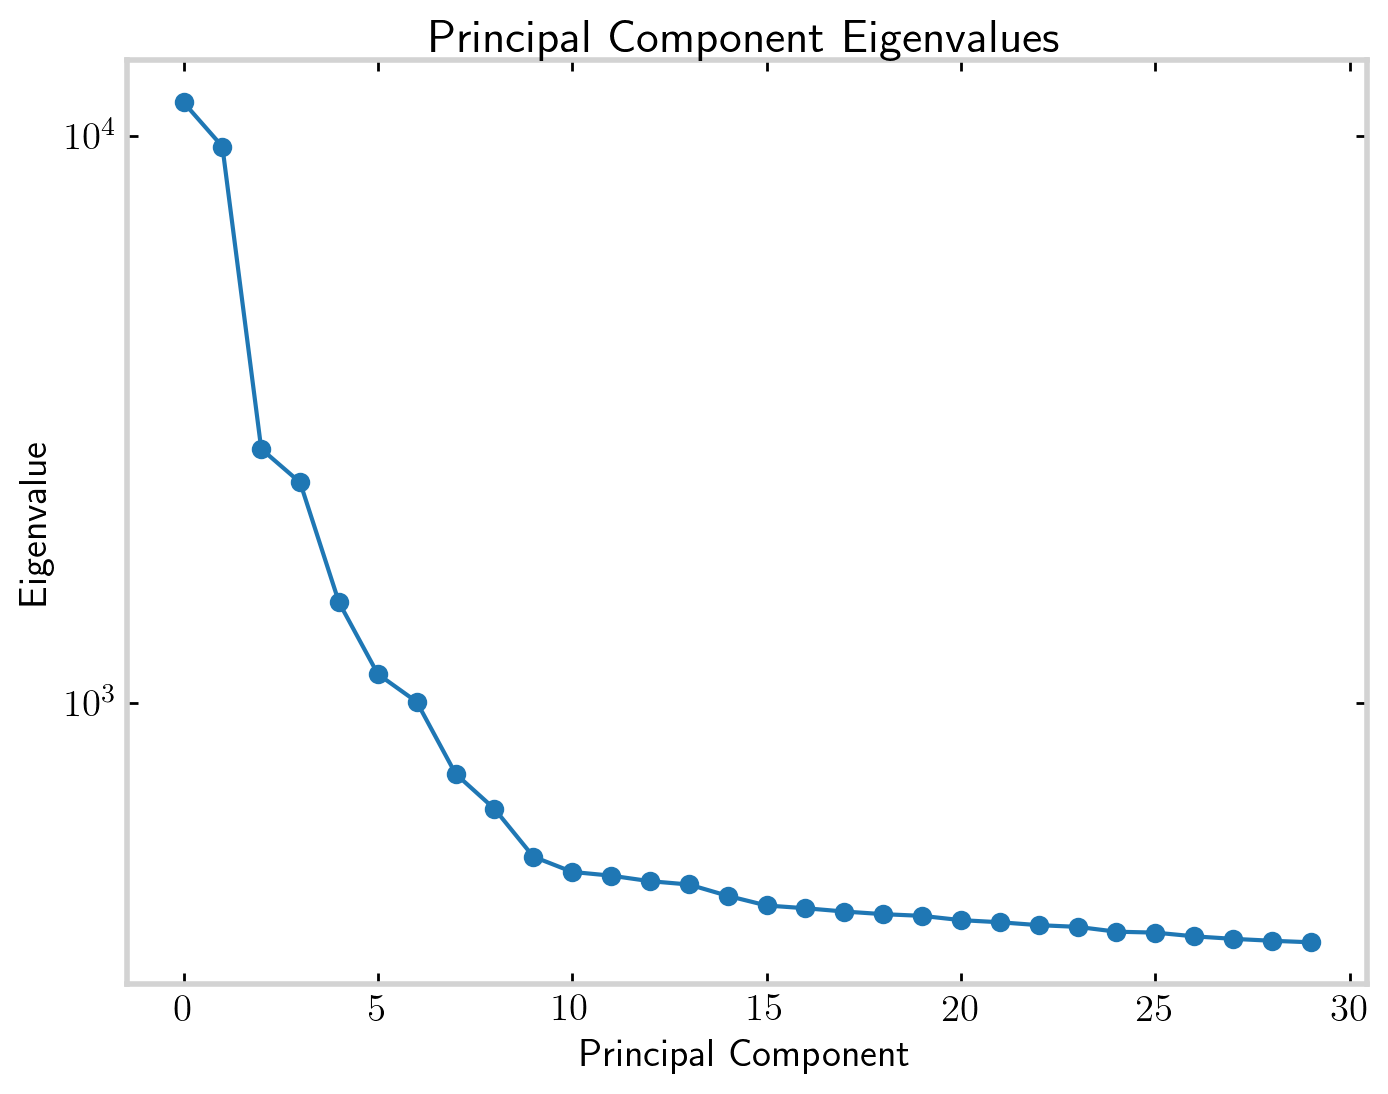

In [11]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue')
    
ax1.set_title('Principal Component Eigenvalues')
plt.savefig(fig_dir+'eigenvalues.pdf')
# plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

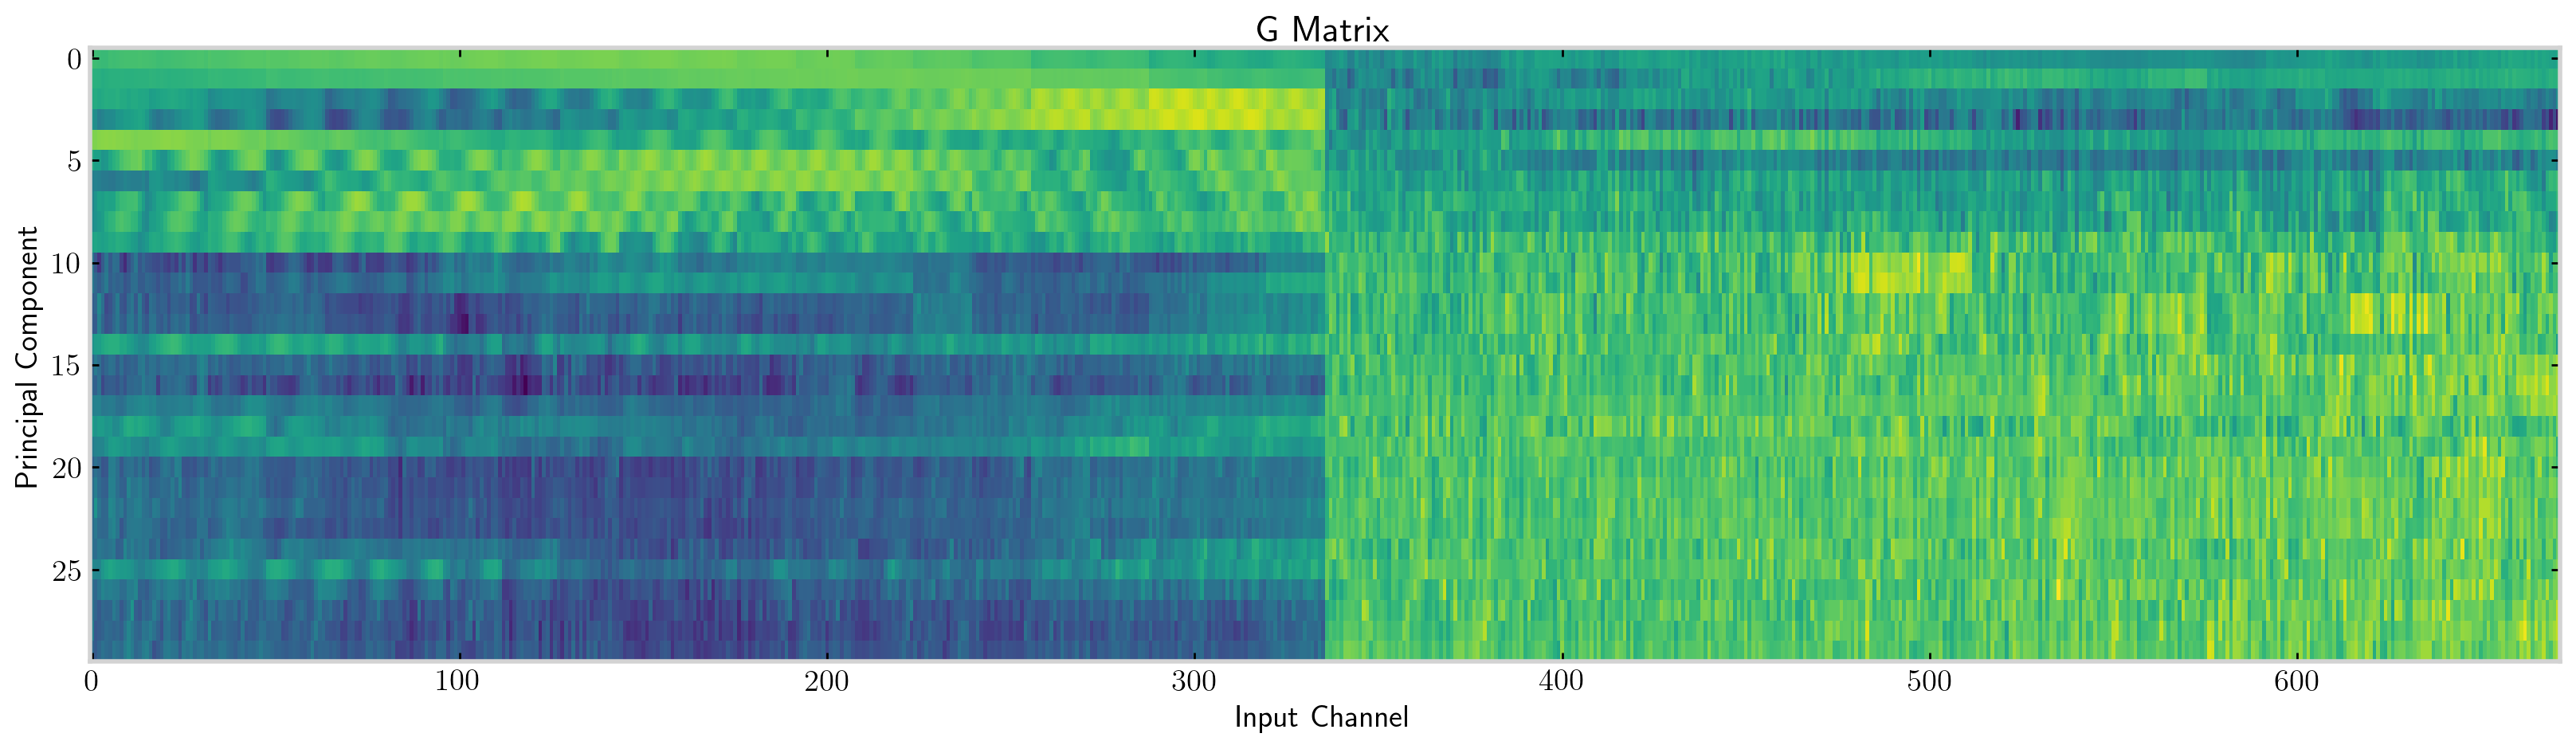

In [14]:
# t1 is each PCs contribution to each channel, t2 is each channels contribution to each PC
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())
plt.xlabel('Input Channel')
plt.ylabel('Principal Component')
plt.title('G Matrix')
plt.show()

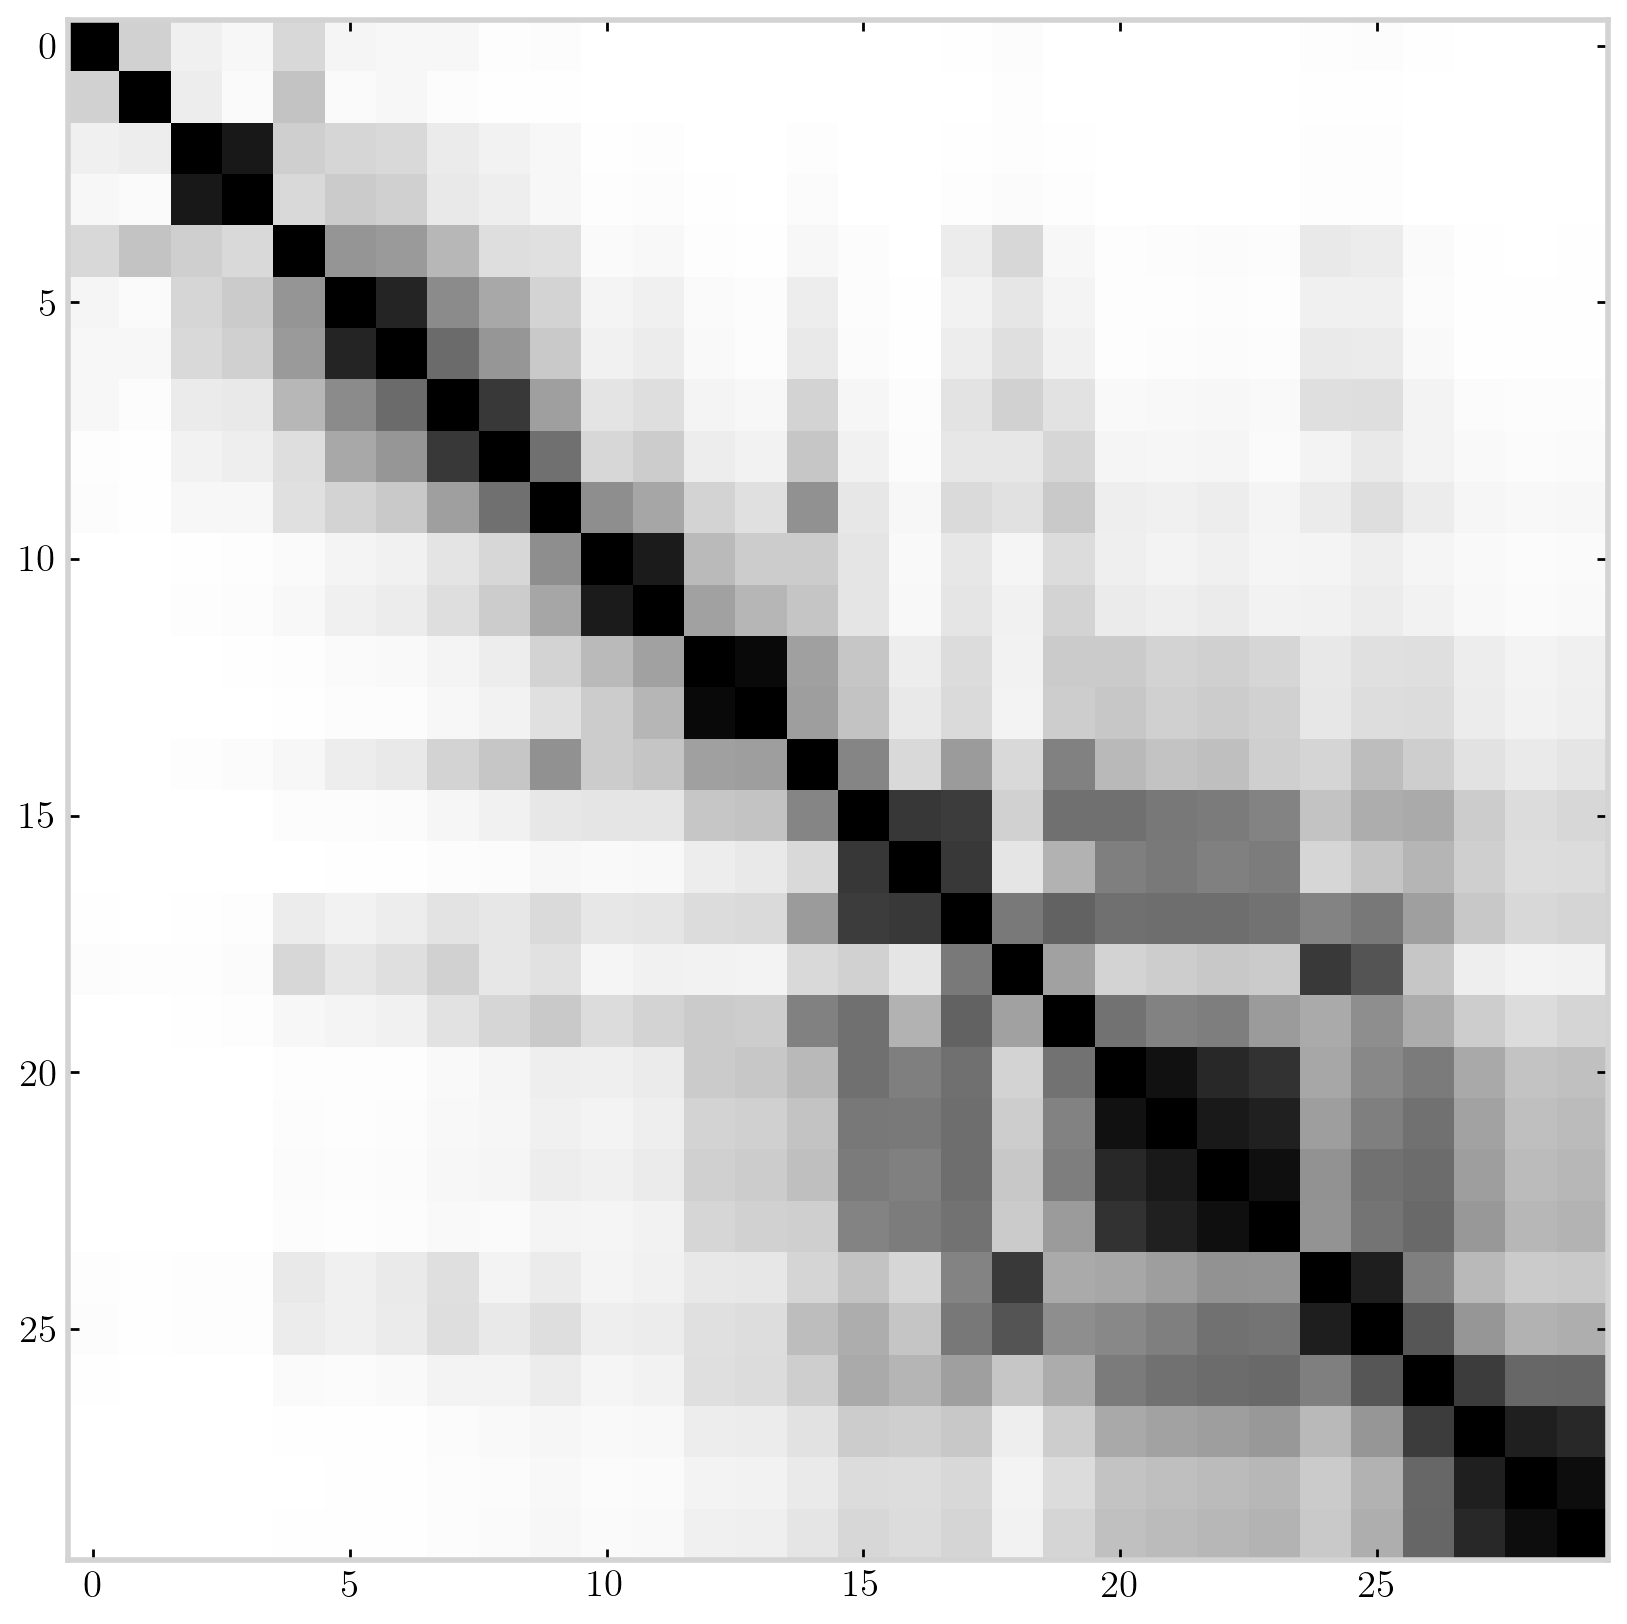

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
plt.savefig(fig_dir+'wCorr30_combined.pdf')
#plt.savefig(fig_dir+'wCorr30.png')
plt.show()

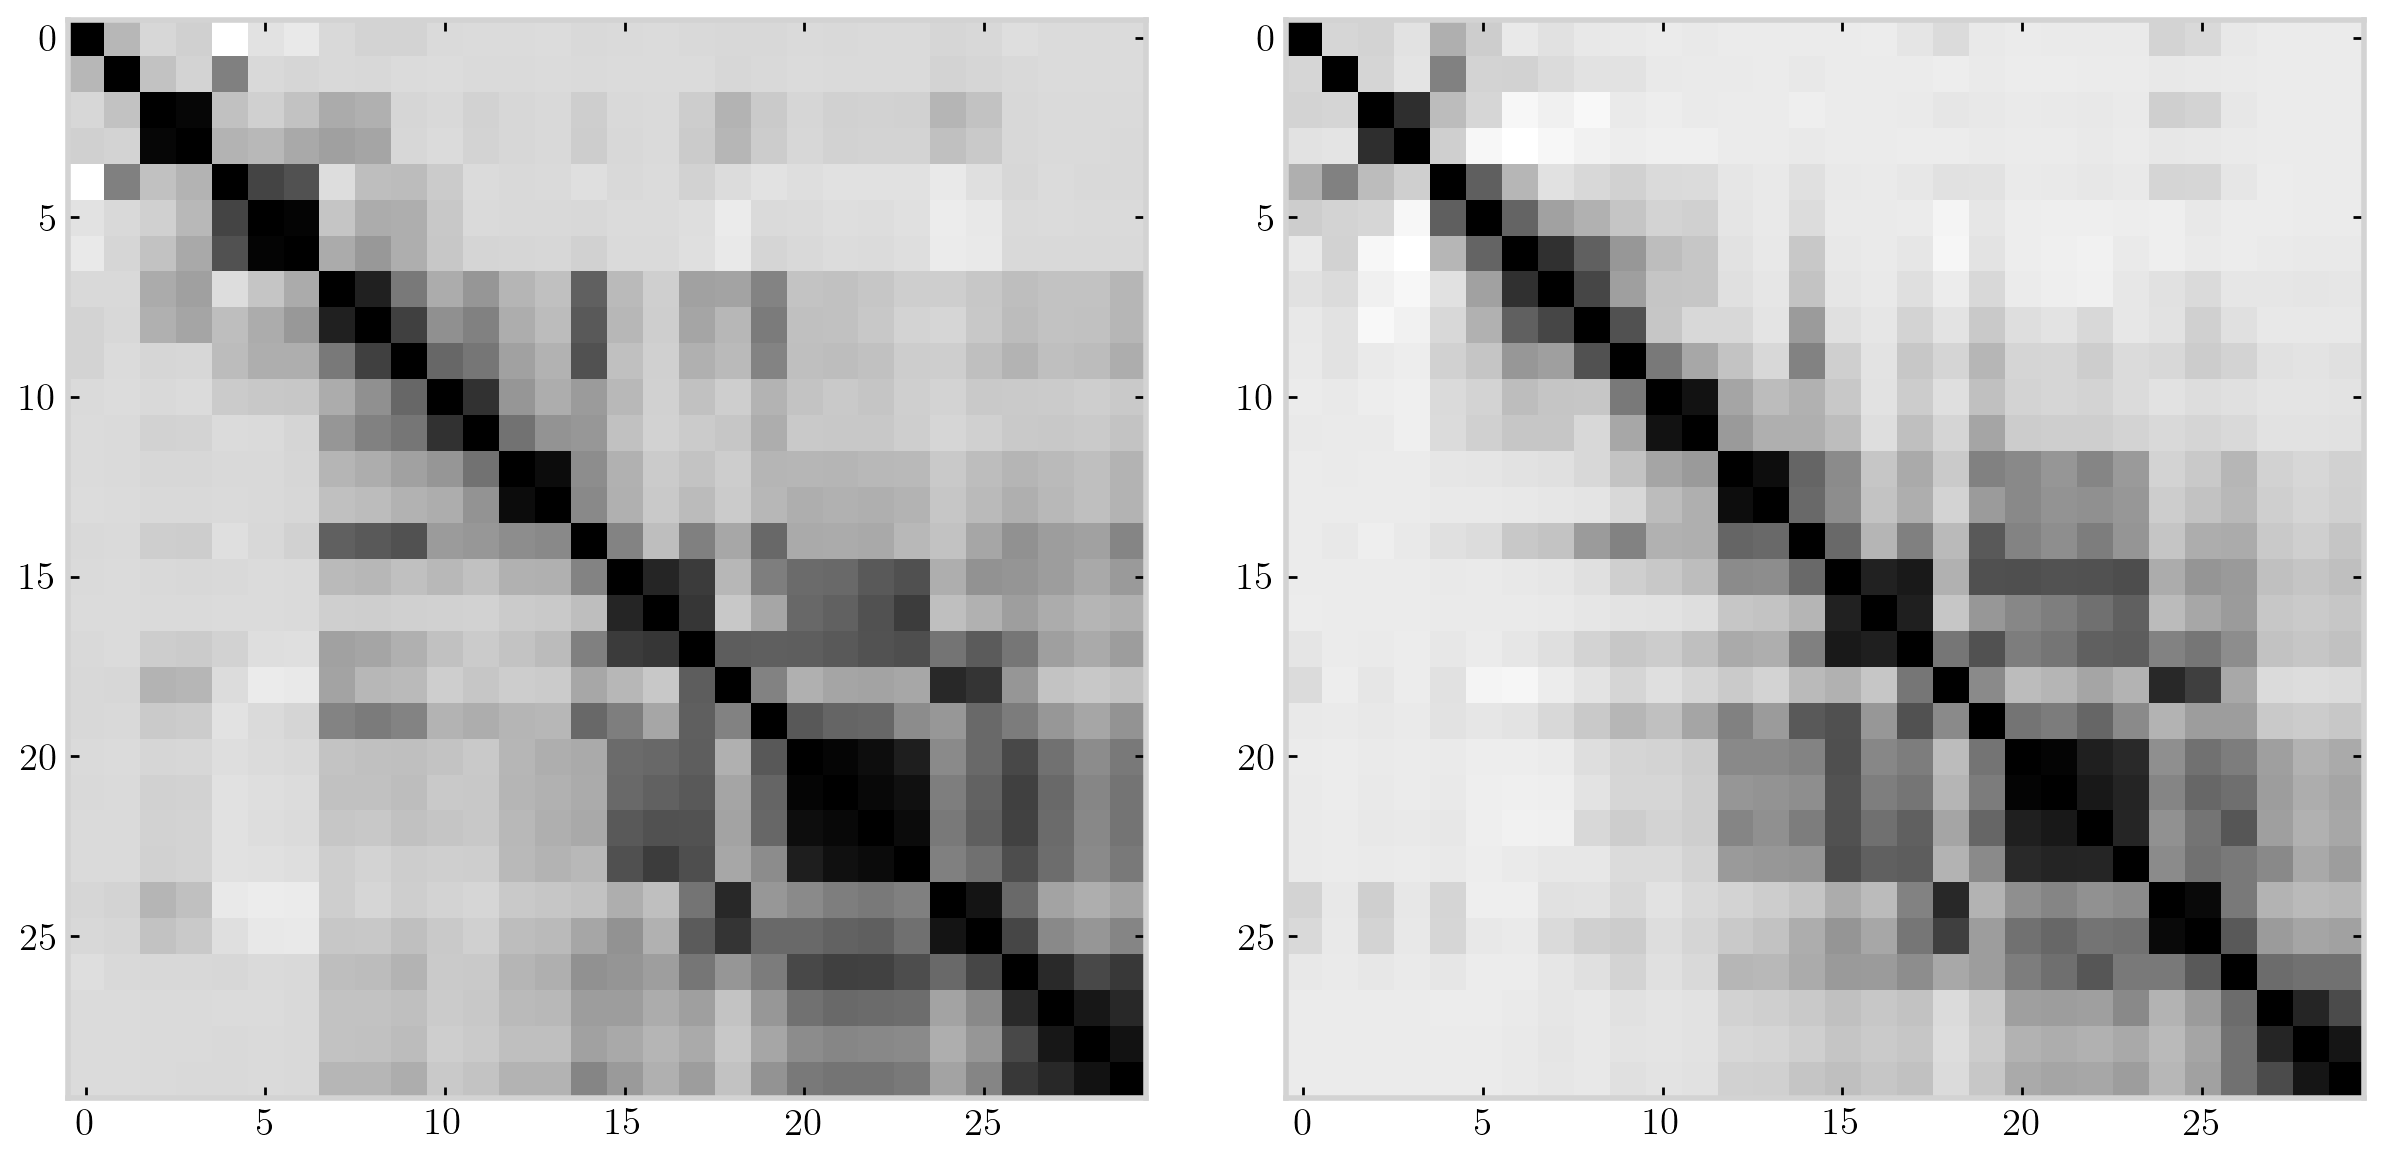

In [17]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.savefig(fig_dir+'wCorr30_individual.pdf')
plt.show()

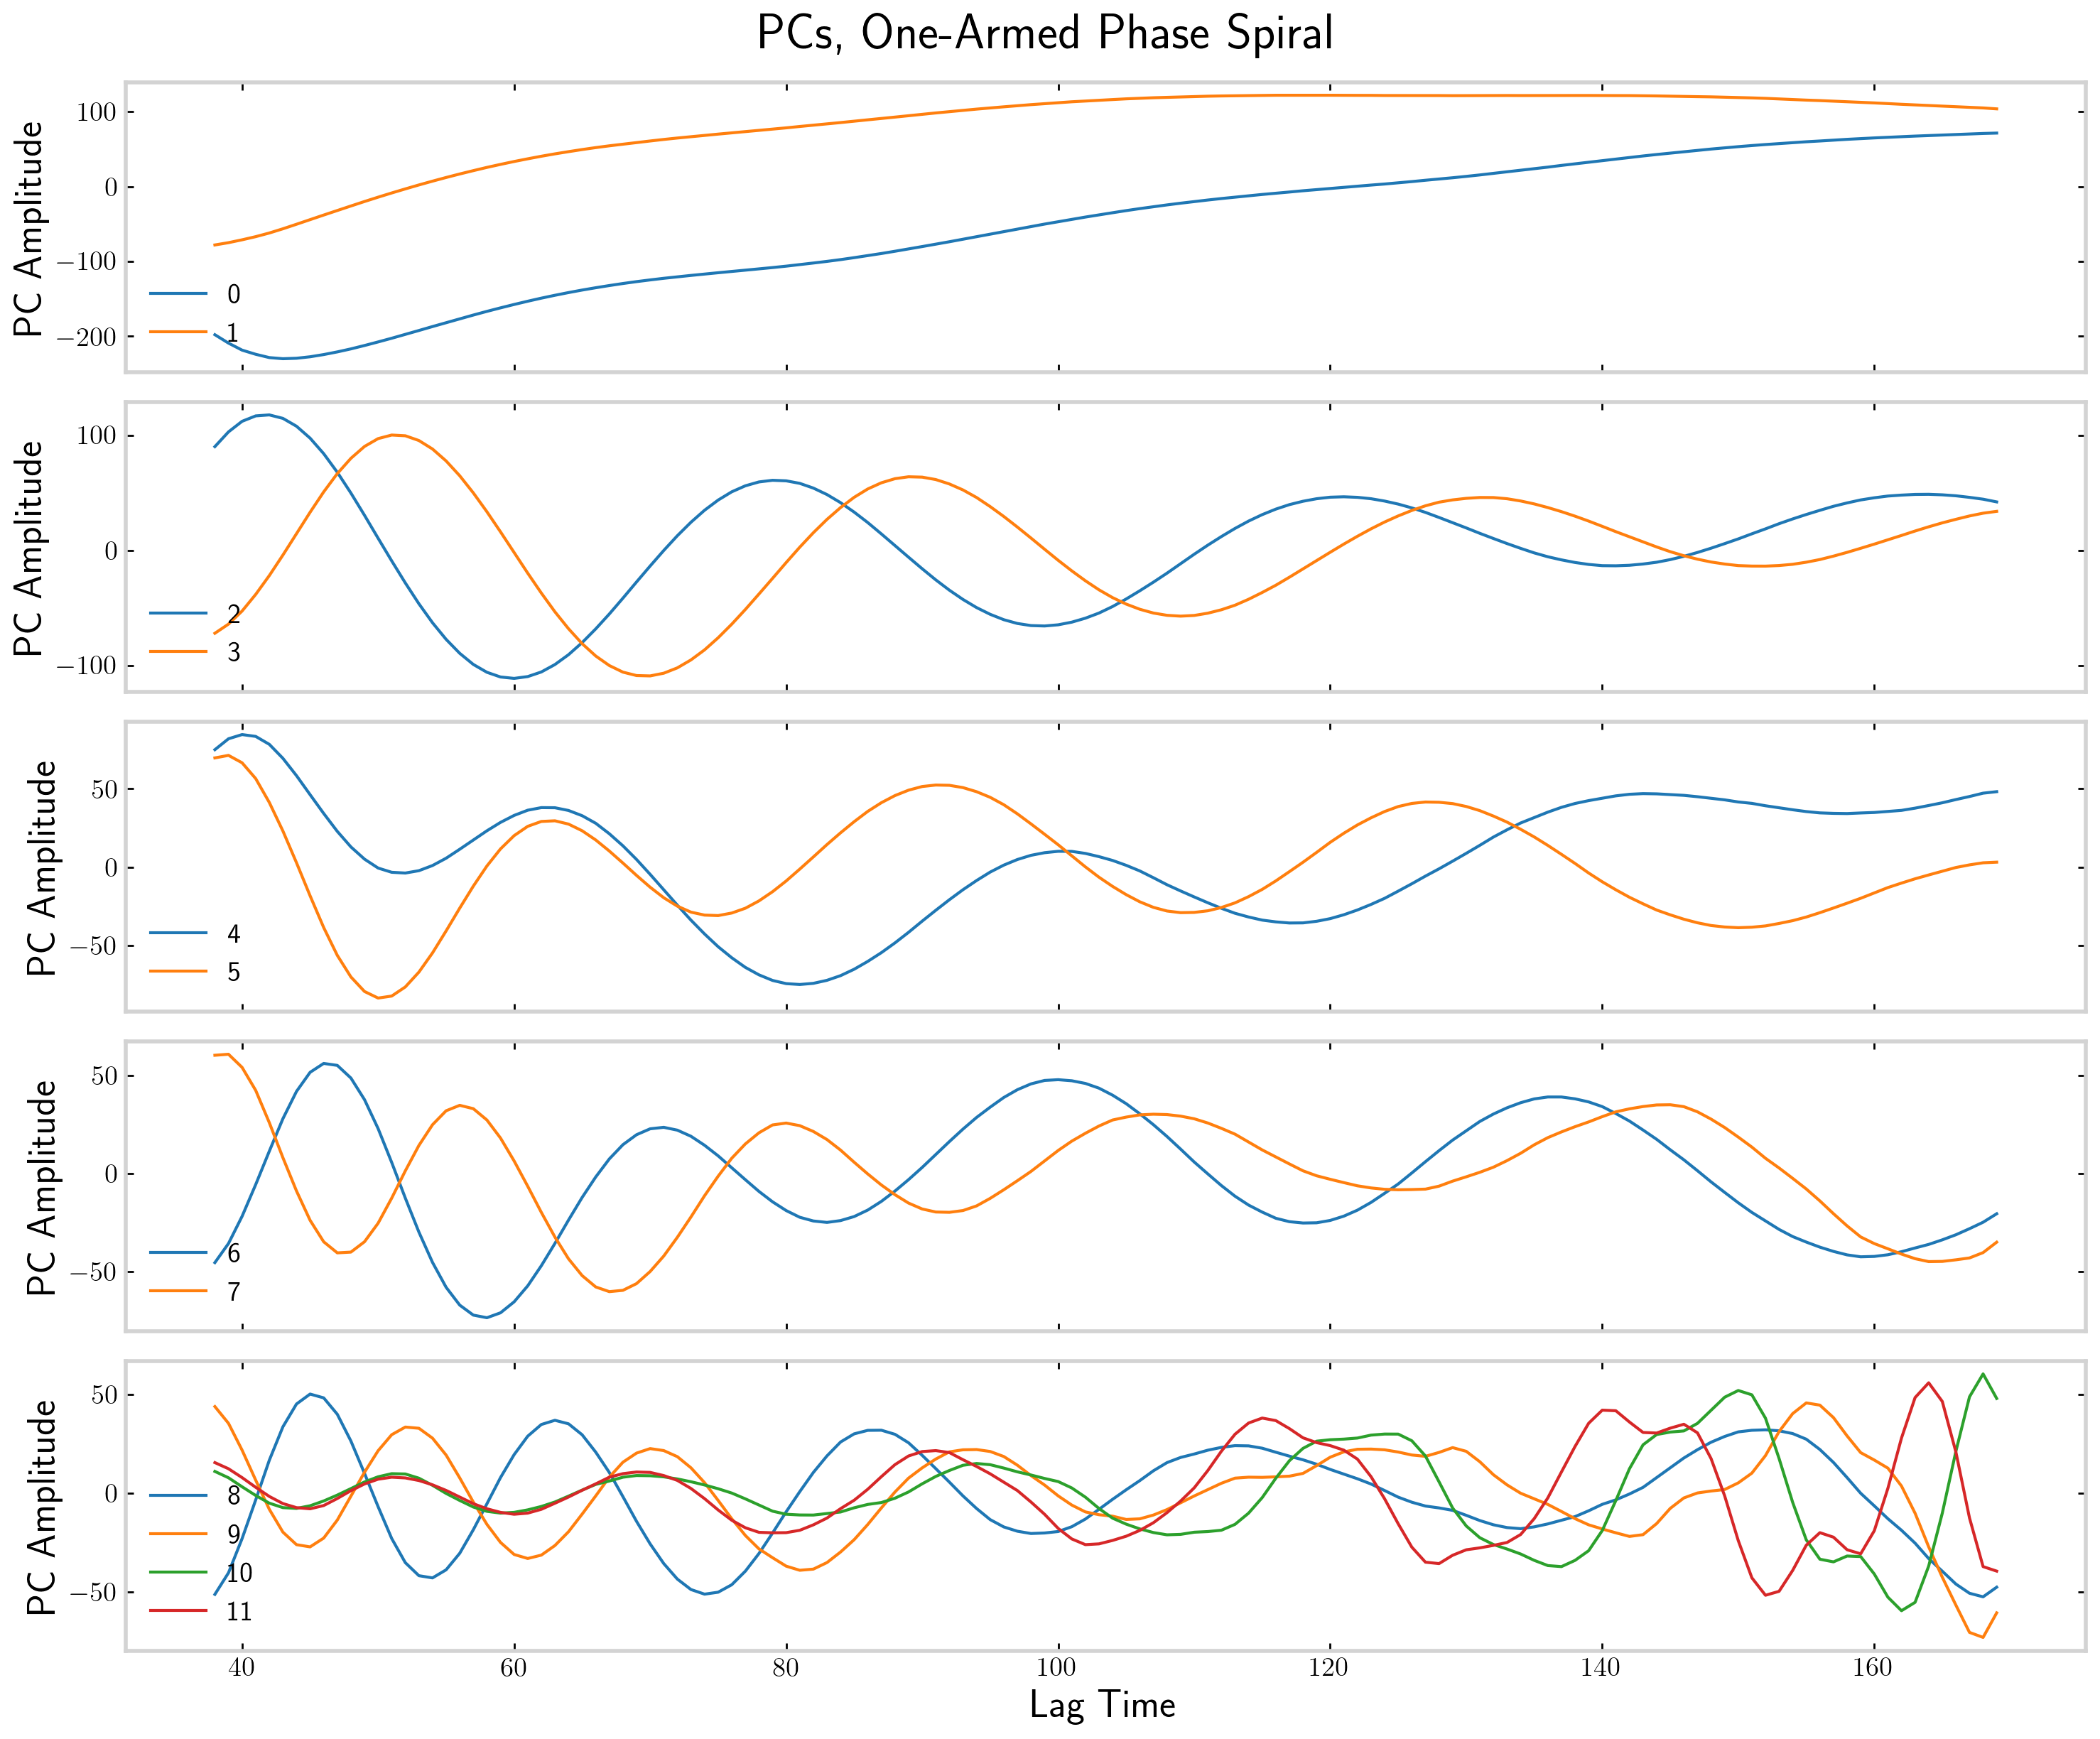

In [18]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, One-Armed Phase Spiral', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Amplitude', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

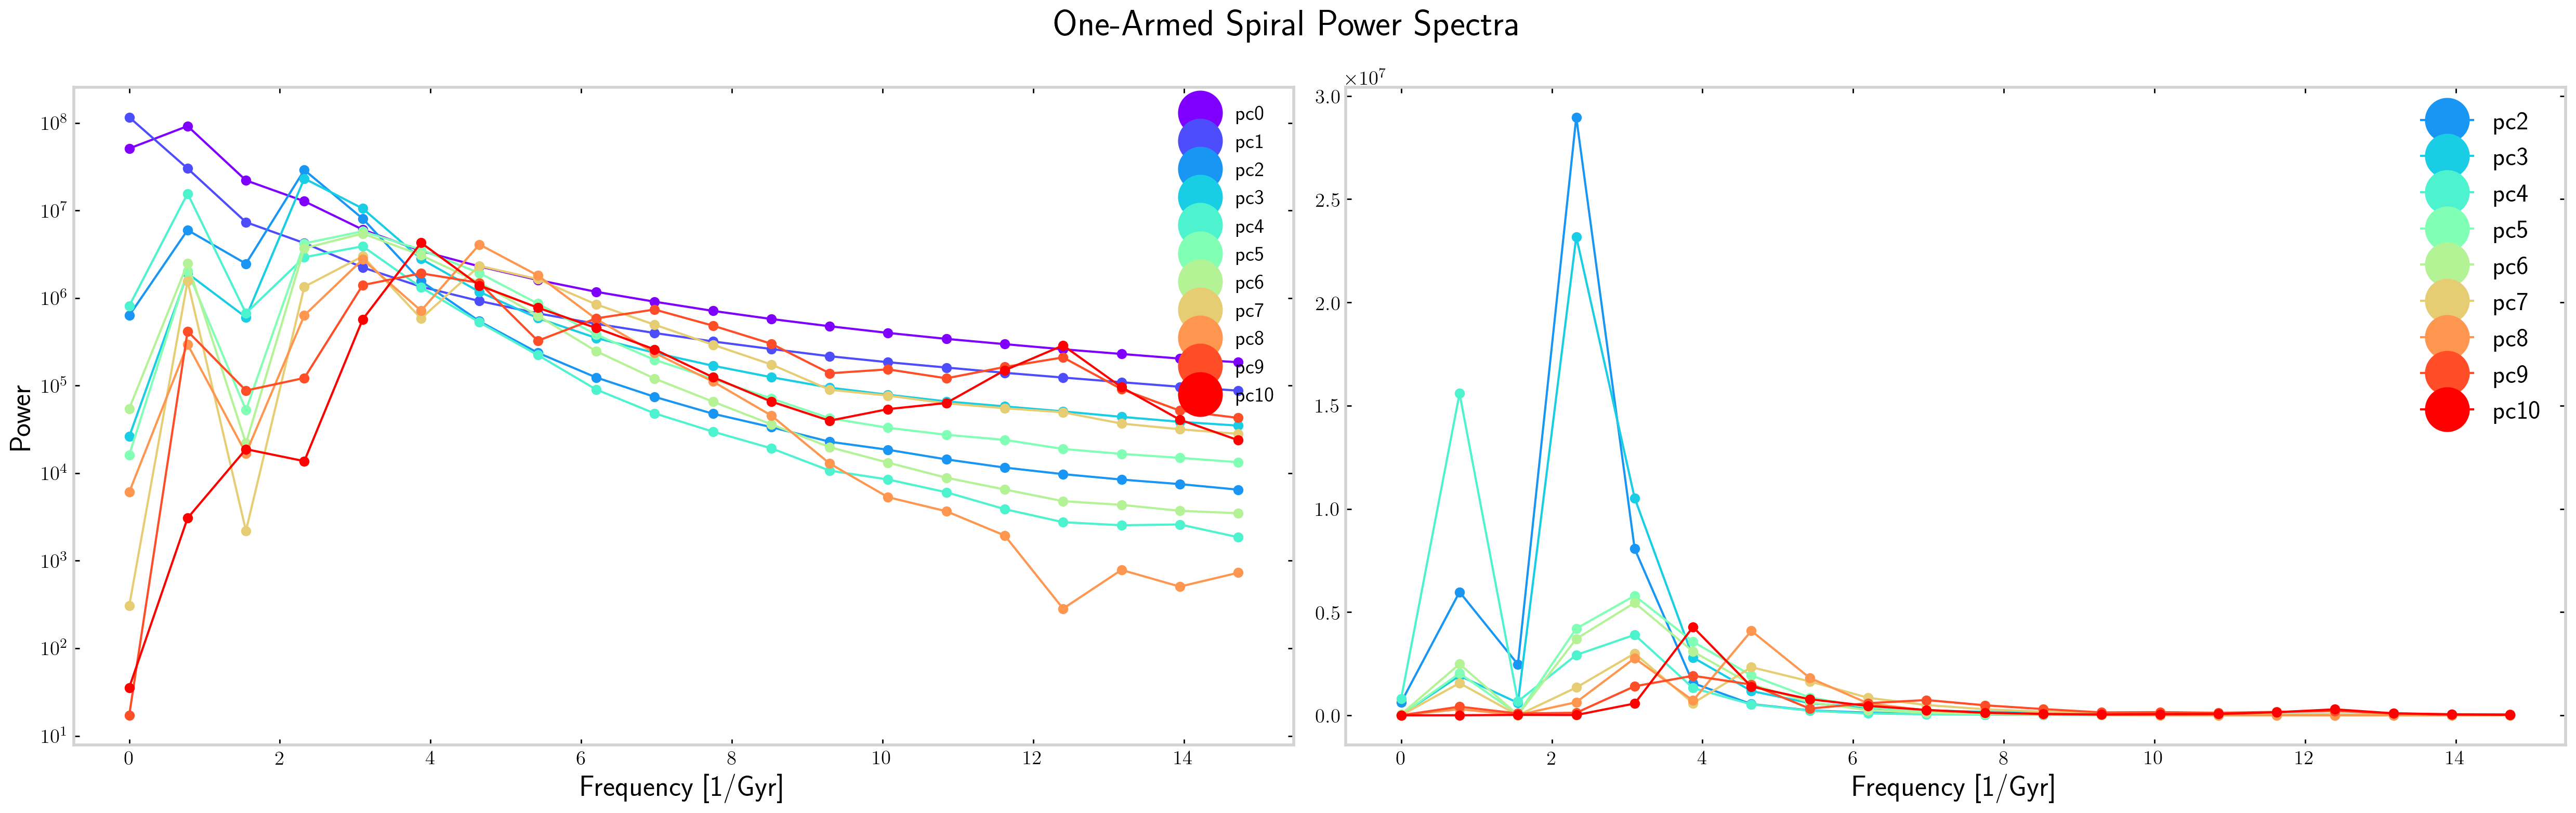

In [19]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(25, 8))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend() ; ax2.legend(fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Spiral Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

In [21]:
freqs = np.load('../data/test_frequency_array_j25.npy')[:21]
freqs

array([7.59670671, 6.97484319, 6.41869093, 5.92313979, 5.48071794,
       5.08427202, 4.73053109, 4.41235123, 4.12851134, 3.87241322,
       3.64171986, 3.43173484, 3.24276922, 3.07077143, 2.91375766,
       2.7700754 , 2.63923324, 2.51938706, 2.40718516, 2.30580754,
       2.21140019])

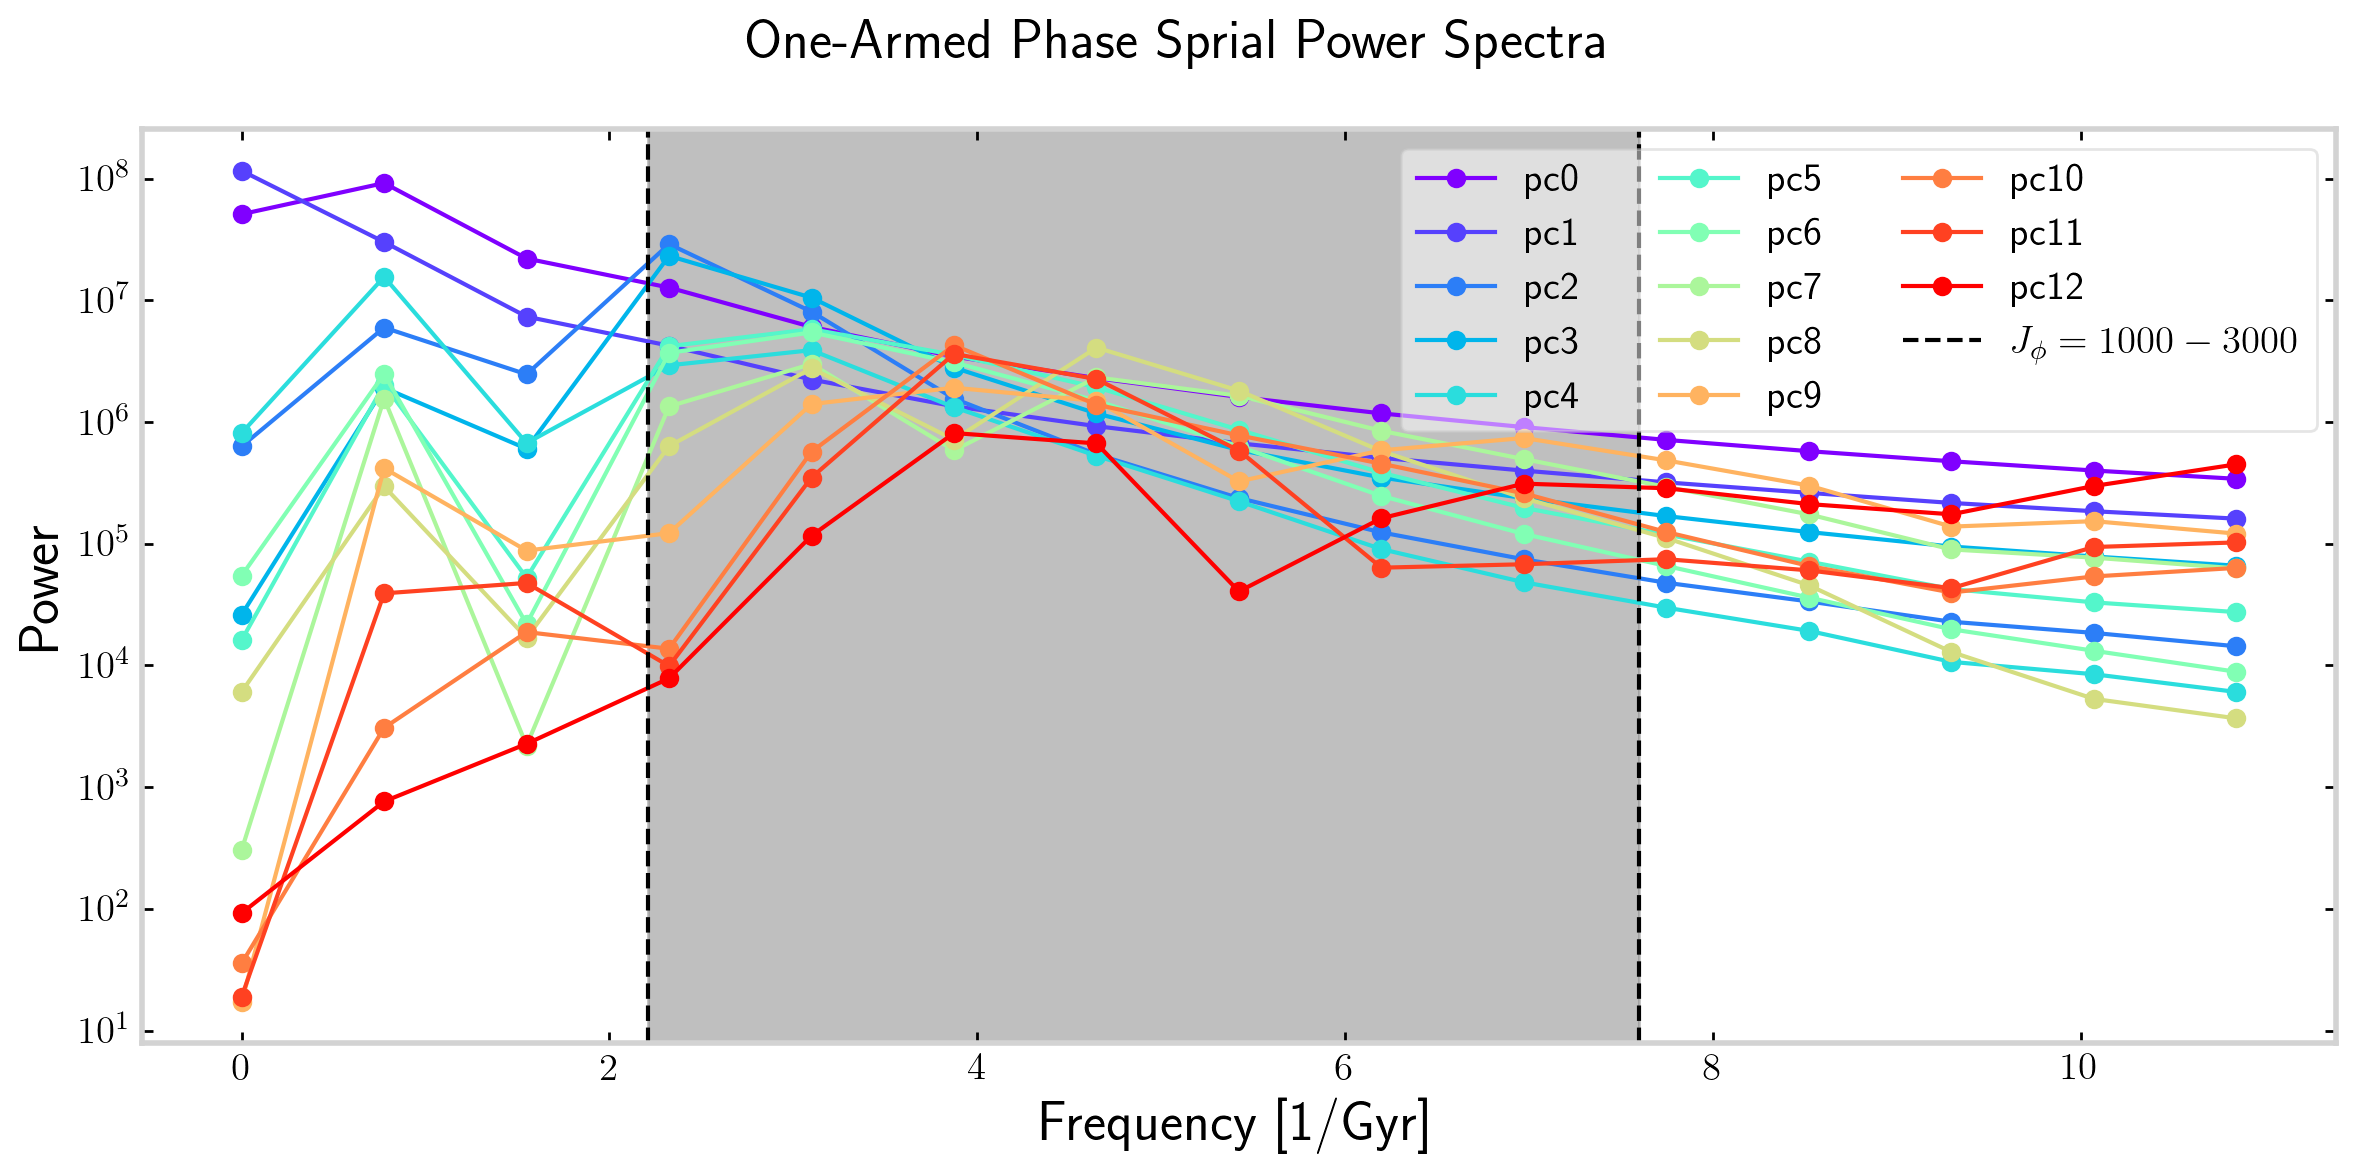

In [30]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))

color = iter(cm.rainbow(np.linspace(0, 1, 13)))

for i in range(0, 13,1):
    c = next(color)
    ax1.plot(freq[:15] * (1/0.009778)/(2*np.pi), power[:15,i], '-o', c=c, label='pc'+str(i))

ax1.axvline(freqs[0], color='k', ls='dashed', label=r'$J_{\phi}=1000-3000$')
ax1.axvline(freqs[-1], color='k', ls='dashed')
ax1.axvspan(freqs[-1], freqs[0], alpha=0.5, color='gray')

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend(markerscale=1, frameon=True, ncols=3)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('One-Armed Phase Sprial Power Spectra', fontsize=20)

fig.tight_layout()
#plt.savefig('/mnt/home/ktavangar/projects/MSSA_Snails/figures/shorter_sim/m1_pitch_power_spectrum.pdf')
plt.show()